# UStar New CycleGAN-based Denoising Model Training

## CycleGAN Training Procedure

1. Create folder structure in Google Colab

In [1]:
import os

os.makedirs("implementations/cyclegan", exist_ok=True)
os.makedirs("data", exist_ok=True)

2. Set to data folder first.

In [2]:
%cd /content/data

/content/data


3. Upload the dataset folder as a zip

In [3]:
# ============================================================
# REMINDER:
# Your dataset **must** follow this exact structure before upload:
#
# UStar_CycleGAN_Sample_Dataset/
# ├── train/
# │   ├── A/
# │   └── B/
# └── test/
#     ├── A/
#     └── B/
#
# Example (from your screenshot):
# UStar_CycleGAN_Sample_Dataset/train/A, UStar_CycleGAN_Sample_Dataset/train/B
# UStar_CycleGAN_Sample_Dataset/test/A,  UStar_CycleGAN_Sample_Dataset/test/B
#
# Upload the root folder (UStar_CycleGAN_Sample_Dataset.zip) containing this structure.
# ============================================================

from google.colab import files
uploaded = files.upload()

import os, shutil

# Ensure directory exists
os.makedirs("/content/data", exist_ok=True)

# Move uploaded files into /content/data
for filename in uploaded.keys():
    shutil.move(filename, f"/content/data/{filename}")

print("Uploaded files have been moved to /content/data")

Saving ustar_real2simulated_2.zip to ustar_real2simulated_2.zip
Uploaded files have been moved to /content/data


4. Unzip the dataset, feel free to change the name "UStar_CycleGAN_Sample_Dataset"  to something else

In [4]:
!cd /content/data
!unzip ustar_real2simulated_2.zip -d ustar_real2simulated_2
!rm ustar_real2simulated_2_@.zip

Archive:  ustar_real2simulated_2.zip
   creating: ustar_real2simulated_2/ustar_real2simulated_2/
   creating: ustar_real2simulated_2/ustar_real2simulated_2/test/
   creating: ustar_real2simulated_2/ustar_real2simulated_2/test/A/
  inflating: ustar_real2simulated_2/ustar_real2simulated_2/test/A/Real (1).png  
  inflating: ustar_real2simulated_2/ustar_real2simulated_2/test/A/Real (14).png  
  inflating: ustar_real2simulated_2/ustar_real2simulated_2/test/A/Real (15).png  
  inflating: ustar_real2simulated_2/ustar_real2simulated_2/test/A/Real (18).png  
  inflating: ustar_real2simulated_2/ustar_real2simulated_2/test/A/Real (2).png  
  inflating: ustar_real2simulated_2/ustar_real2simulated_2/test/A/Real (25).png  
  inflating: ustar_real2simulated_2/ustar_real2simulated_2/test/A/Real (26).png  
  inflating: ustar_real2simulated_2/ustar_real2simulated_2/test/A/Real (32).png  
  inflating: ustar_real2simulated_2/ustar_real2simulated_2/test/A/Real (38).png  
  inflating: ustar_real2simulated_2

5. Upload the CycleGAN source code from PC

In [5]:
from google.colab import files
uploaded = files.upload()

# move uploaded files into the target folder
import shutil

for filename in uploaded.keys():
    shutil.move(filename, "/content/implementations/cyclegan/" + filename)

print("Files uploaded to /content/implementations/cyclegan/")

Saving cyclegan.py to cyclegan.py
Saving datasets.py to datasets.py
Saving models.py to models.py
Saving utils.py to utils.py
Files uploaded to /content/implementations/cyclegan/


6. Run the CycleGAN code

In [12]:
# --epoch                 : Epoch to start training from (0 = fresh training)
# --n_epochs              : Total number of epochs to train
# --dataset_name          : Name of the dataset folder (must include trainA/trainB and testA/testB)
# --batch_size            : Number of images per batch
# --lr                    : Learning rate for Adam optimizer
# --b1                    : Adam optimizer beta1 (momentum term)
# --b2                    : Adam optimizer beta2 (momentum term)
# --decay_epoch           : Epoch when learning rate decay begins
# --n_cpu                 : Number of CPU threads for data loading
# --img_height            : Input image height
# --img_width             : Input image width
# --channels              : Image channels (3 = RGB)
# --sample_interval       : Save generated images every N batches
# --checkpoint_interval   : Save model checkpoints every N epochs (-1 disables saving)
# --n_residual_blocks     : Number of ResNet residual blocks in the generator
# --lambda_cyc            : Weight for cycle-consistency loss
# --lambda_id             : Weight for identity loss (0 = disable identity loss)

# Set the directory
!cd /content/implementations/cyclegan

# Run the source code
!python3 /content/implementations/cyclegan/cyclegan.py \
  --dataset_name ustar_real2simulated \
  --epoch 0 \
  --n_epochs 300 \
  --decay_epoch 150 \
  --batch_size 1 \
  --lr 0.0002 \
  --b1 0.5 \
  --b2 0.999 \
  --img_height 128 \
  --img_width 128 \
  --channels 3 \
  --n_residual_blocks 6 \
  --lambda_cyc 5.0 \
  --lambda_id 1.0 \
  --sample_interval 60 \
  --checkpoint_interval 1

Namespace(epoch=0, n_epochs=300, dataset_name='ustar_real2simulated', batch_size=1, lr=0.0002, b1=0.5, b2=0.999, decay_epoch=150, n_cpu=8, img_height=128, img_width=128, channels=3, sample_interval=60, checkpoint_interval=1, n_residual_blocks=6, lambda_cyc=5.0, lambda_id=1.0)

Please enter the FULL dataset path (folder containing train/ and test/):
Dataset path: /content/data/ustar_real2simulated_2/ustar_real2simulated_2
Using dataset path: /content/data/ustar_real2simulated_2/ustar_real2simulated_2
>>> #Train Images: 57
>>> #Test Images: 12
/content/implementations/cyclegan/cyclegan.py:197: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:78.)
  valid = Variable(Tensor(np.ones((real_A.size(0), *D_A.output_shape))), requires_grad=False)
[Epoch 299/300] [Batch 56/57] [D loss: 0.104234] [G loss

7. Display generated images to users.

Enter the dataset name (the folder inside images/): ustar_real2simulated
Showing: images/ustar_real2simulated/9960.png


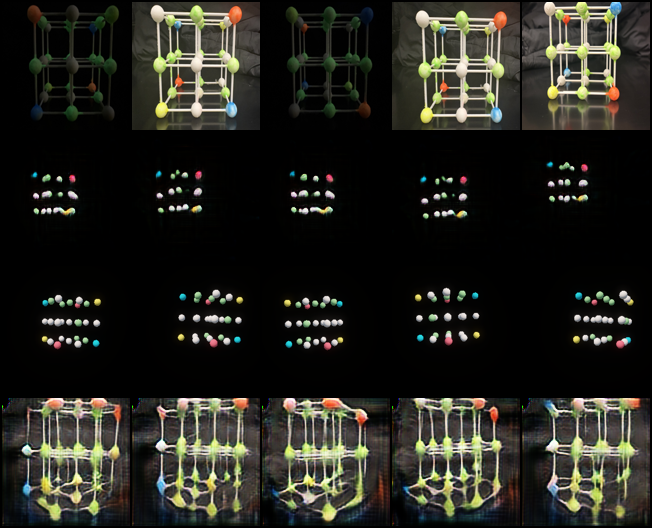

In [13]:
import glob
import os
from IPython.display import Image, display

# Ask user for dataset folder name
user_ds = input("Enter the dataset name (the folder inside images/): ").strip()

sample_dir = os.path.join("images", user_ds)
pngs = sorted(glob.glob(os.path.join(sample_dir, "*.png")))

if not pngs:
    print(f"No PNG samples found in: {sample_dir}")
else:
    latest_sample = pngs[-1]
    print("Showing:", latest_sample)
    display(Image(filename=latest_sample))

8. Convert pth file into ptl file for mobile inference

In [14]:
import os
import glob
import sys
import torch
from torch.utils.mobile_optimizer import optimize_for_mobile

# 1) Import models
cyclegan_root = "/content/implementations/cyclegan"
if cyclegan_root not in sys.path:
    sys.path.append(cyclegan_root)

from models import GeneratorResNet   # same class used in cyclegan.py

device = torch.device("cpu")

# 2) Hyperparameters (must match training)
channels = 3
img_height = 128
img_width = 128
n_residual_blocks = 6
input_shape = (channels, img_height, img_width)

# 3) Automatically pick G_AB checkpoint closest to epoch 200
target_epoch = 300

g_ab_files = glob.glob("saved_models/ustar_real2simulated/G_AB_*.pth")
if not g_ab_files:
    raise FileNotFoundError("No G_AB_*.pth files found in saved_models/uoid_real2unity3d")

def get_epoch(path):
    name = os.path.splitext(os.path.basename(path))[0]  # e.g. G_AB_198
    try:
        return int(name.split("_")[-1])
    except ValueError:
        return -1

candidates = [(p, get_epoch(p)) for p in g_ab_files if get_epoch(p) >= 0]
ckpt_path, epoch = min(candidates, key=lambda x: abs(x[1] - target_epoch))

print("Chosen checkpoint:", ckpt_path, "(epoch:", epoch, ")")

# 4) Rebuild G_AB exactly as in training
G_AB = GeneratorResNet(input_shape, n_residual_blocks).to(device)

# 5) Load weights
state_dict = torch.load(ckpt_path, map_location="cpu")
G_AB.load_state_dict(state_dict)
G_AB.eval().cpu()
for p in G_AB.parameters():
    p.requires_grad_(False)

# 6) Script/trace + optimize for mobile
example = torch.randn(1, channels, img_height, img_width)

with torch.inference_mode():
    try:
        ts = torch.jit.script(G_AB)
        print("Used torch.jit.script")
    except Exception as e:
        print("torch.jit.script failed, falling back to torch.jit.trace:", e)
        ts = torch.jit.trace(G_AB, example)

ts_optimized = optimize_for_mobile(ts)

# 7) Save .ptl
os.makedirs("mobile", exist_ok=True)
base_name = os.path.splitext(os.path.basename(ckpt_path))[0]
out_ptl_path = os.path.join("mobile", base_name + "_mobile.ptl")

ts_optimized._save_for_lite_interpreter(out_ptl_path)
print("\nSaved Lite-interpreter model to:", out_ptl_path)

# 8) Let user download (Colab)
try:
    from google.colab import files
    files.download(out_ptl_path)
    print("Download started…")
except Exception as e:
    print("Could not auto-download (not in Colab?):", e)
    print("Please manually download the file at:", out_ptl_path)

Chosen checkpoint: saved_models/ustar_real2simulated/G_AB_299.pth (epoch: 299 )
Used torch.jit.script

Saved Lite-interpreter model to: mobile/G_AB_299_mobile.ptl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started…
